In [143]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
torch.cuda.is_available()

False

In [ ]:
from torchvision.transforms import ToTensor

dataset_train = torchvision.datasets.MNIST(
    root='./data',
    train= True,
    transform=ToTensor(),
    download=True,
)
dataset_test = torchvision.datasets.MNIST(
    root='./data',
    train= False,
    transform=ToTensor(),
    download=True,
)

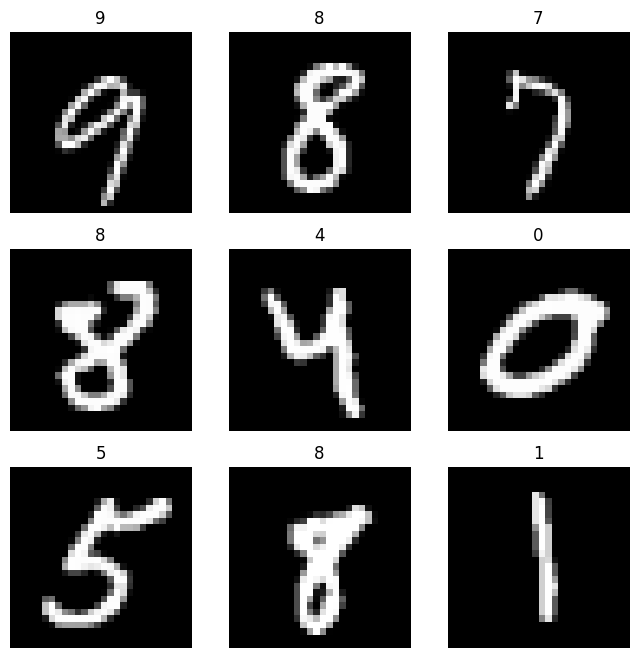

In [145]:
figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3
for i in range(1, cols*rows+1):
    sample_idx = torch.randint(len(dataset_train), size=(1,)).item()
    img, label = dataset_train[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [146]:
from torch.utils.data import DataLoader

dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

In [147]:
train_features, train_labels = next(iter(dataloader_train))
train_features.size()

torch.Size([64, 1, 28, 28])

In [ ]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)
        self.softmax = nn.Softmax()
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.softmax(x)
        return x

In [149]:
mlp = MLP()

print(mlp)

n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"\n[2.3] Paramètres entraînables : {n_params:,}")

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (softmax): Softmax(dim=None)
)

[2.3] Paramètres entraînables : 109,386


In [150]:
x_dummy = torch.randn(1, 784)
output = mlp(x_dummy)
print(f"\n[2.4] Forward pass : entrée {x_dummy.shape} --> {output.shape}")
print(f"Sortie : {output}")


[2.4] Forward pass : entrée torch.Size([1, 784]) --> torch.Size([1, 10])
Sortie : tensor([[0.1165, 0.0965, 0.1014, 0.0967, 0.1053, 0.0793, 0.0944, 0.0953, 0.0937,
         0.1209]], grad_fn=<SoftmaxBackward0>)


In [151]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3)

In [152]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y_true) in enumerate(dataloader):
        y_pred = model(X)
        loss = loss_fn(y_pred, y_true)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * 64 + len(X)
            print(f"loss : {loss:>7f}   [{current:>5d} / {size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y_true in dataloader:
            y_pred = model(X)
            test_loss += loss_fn(y_pred, y_true).item()
            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()
    
    test_loss /= num_batches
    correct /= size

    print(f"Test error : Accuracy : {(100 * correct):>0.1f}%, Avg loss : {test_loss:>8f}")

In [153]:
epochs = 5
for t in range(epochs):
    print("Epoch :", t+1)
    train_loop(dataloader_train, mlp, criterion, optimizer)
    test_loop(dataloader_test, mlp, criterion)

print("Done")

Epoch : 1
loss : 2.303119   [   64 / 60000]
loss : 1.737441   [ 6464 / 60000]
loss : 1.643418   [12864 / 60000]
loss : 1.558700   [19264 / 60000]
loss : 1.548032   [25664 / 60000]
loss : 1.583885   [32064 / 60000]
loss : 1.555729   [38464 / 60000]
loss : 1.515220   [44864 / 60000]
loss : 1.573948   [51264 / 60000]
loss : 1.522418   [57664 / 60000]
Test error : Accuracy : 93.1%, Avg loss : 1.533965
Epoch : 2
loss : 1.547892   [   64 / 60000]
loss : 1.518529   [ 6464 / 60000]
loss : 1.535770   [12864 / 60000]
loss : 1.523503   [19264 / 60000]
loss : 1.530046   [25664 / 60000]
loss : 1.498195   [32064 / 60000]
loss : 1.463076   [38464 / 60000]
loss : 1.543048   [44864 / 60000]
loss : 1.511670   [51264 / 60000]
loss : 1.523460   [57664 / 60000]
Test error : Accuracy : 94.9%, Avg loss : 1.515694
Epoch : 3
loss : 1.468128   [   64 / 60000]
loss : 1.522697   [ 6464 / 60000]
loss : 1.513385   [12864 / 60000]
loss : 1.501226   [19264 / 60000]
loss : 1.518750   [25664 / 60000]
loss : 1.503483   